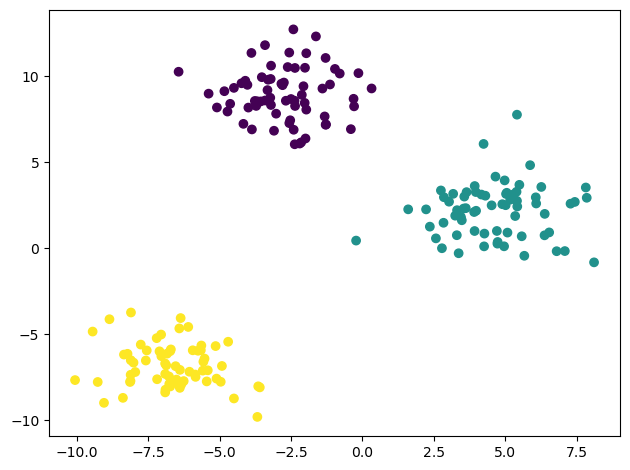

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [ ]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터 생성
X, y = make_blobs(
    n_samples=200, centers=3, cluster_std=1.5, random_state=42
)

# 시각화
plt.scatter(X[:,0],X[:,1], c=y)
plt.tight_layout()
plt.show()

In [5]:
from sklearn.cluster import KMeans

k=5
kmeans = KMeans(n_clusters=5)
y_predict = kmeans.fit_predict(X)

c:\Users\dlqkf\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


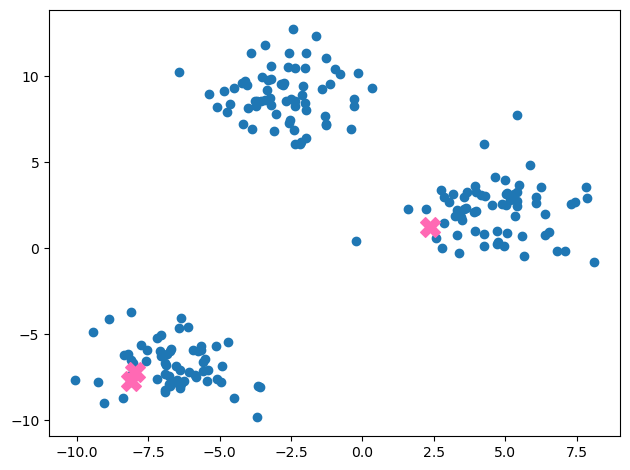

In [7]:
import numpy as np

# step1 - 초기중심: 처음 중심을 랜덤으로 선택
k=3
np.random.seed(42)
indicies = np.random.choice(len(X), k, replace=False)
centroids = X[indicies]
plt.scatter(X[:,0],X[:,1])
plt.scatter(centroids[:,0],centroids[:,1],c='hotpink',marker='X',s=200)
plt.tight_layout()
plt.show()

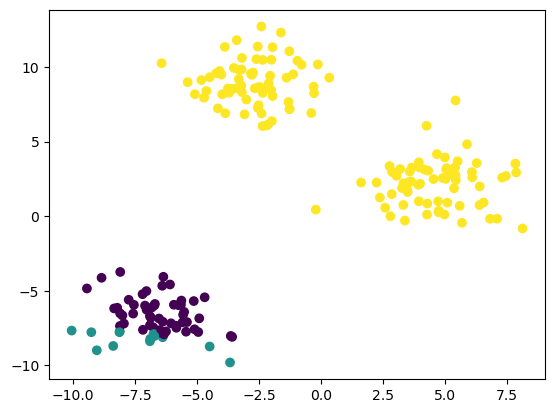

In [14]:
# step2 각 점을 가장 가까운 중심에 할당
# 거리계산 -> 가장 가까운 중심 선택
def assign_cluster(X, centroids):
    distance = np.linalg.norm(X[:, np.newaxis]-centroids, axis=2)
    return np.argmin(distance,axis=1)
labels = assign_cluster(X,centroids)
labels

# 각 점이 0,1,2중 하나로 배정됨
plt.scatter(X[:,0],X[:,1],c=labels)

In [18]:
print(X.shape, X[:,np.newaxis].shape, centroids.shape)
# newaxis 새로운 축 추가
# 점 200개 x centroid 3개 x 좌표2
# 첫번째 점  [1,2]
# centroid : [3,4] [5,6] [7,8]
# [1-3, 2-4] [1-5, 2-6], [1-7, 2-8]
# 모든 centroid와의 좌표계산
# 유클리드거리 (np.linalg.norm)   (x차이**2 + y차이**2)(1/2) axis=2 좌표방향
# np.argmin(distance,axis=1) 가장 가까운 centroid 선택

(200, 2) (200, 1, 2) (3, 2)


In [19]:
# step3 중심이동
# 각 그룹의 평균을 계산 --> 새로운 중심
def update_centroid(X,labels,k):
    return np.array(
        [X[labels==i].mean(axis=0) for i in range(k)]
    )

centroids = update_centroid(X,labels,k)
centroids

array([[-6.52538496, -6.47920158],
       [-7.30160668, -8.29627639],
       [ 0.94735044,  5.54722254]])

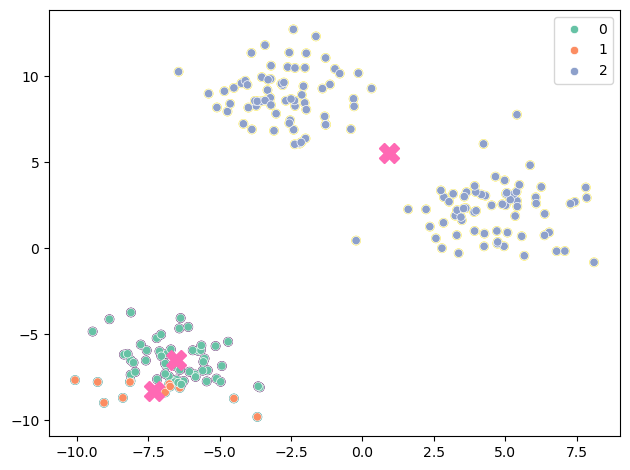

In [26]:
# 새로운 중심점을 좌표에 업데이트
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(X[:,0],X[:,1],c=labels)
plt.scatter(centroids[:,0],centroids[:,1],c='hotpink',marker='X',s=200)
plt.tight_layout()

# 새로운 중심점을 기준으로 label을 분리해서 시각화
sns.scatterplot(x=X[:,0],y=X[:,1],hue=labels,palette='Set2')
plt.scatter(centroids[:,0],centroids[:,1],c='hotpink',marker='X',s=200)
plt.tight_layout()